In [2]:
%matplotlib widget
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

In [3]:
plt.rcParams.update({
    "font.size": 13,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

In [4]:
# path_to_file = Path('/Users/matheussilva/Documents/meetings_notes/paper_post_processed_data')
path_to_file = Path('/media/matheustolen/Seagate Basic/data_to_jaba/cloudnet/cloud_classification/microphysics_stats')
path_fig     = Path("/media/matheustolen/Seagate Basic/data_to_jaba/cloudnet/cloud_classification/figures")

In [5]:
# Read all data in path to file and put then in a dictionary with the name of the file as key:
data = {}
for file in path_to_file.glob('*.nc'):
    data[file.stem] = xr.open_dataset(file)

In [6]:
# Print the keys of the dictionary:
for key in data.keys():
    print(key)

monthly_iwc_for_Ice-Precipitable_ndata_per_height_orig
monthly_resampled_lwc_for_Mixed-Phase
stats_ier_for_Ice_by_month
atmosphere_classification
cloud_macrophysics_corrected_by_attenuation
cloud_occurence_per_cloud_type
integrated_iwc_for_Ice-Precipitable
integrated_iwc_for_Ice
integrated_iwc_for_Mixed-Phase
integrated_lwc_for_Mixed-Phase
monthly_der_for_Mixed-Phase_ndata_per_height_orig
monthly_der_nprofile_for_Mixed-Phase
monthly_ier_for_Ice-Precipitable_ndata_per_height_orig
monthly_ier_for_Ice_ndata_per_height_orig
monthly_ier_for_Mixed-Phase_ndata_per_height_orig
monthly_ier_nprofile_for_Ice-Precipitable
monthly_ier_nprofile_for_Ice
monthly_ier_nprofile_for_Mixed-Phase
seasonal_der_for_Mixed-Phase_ndata_per_height_orig
seasonal_ier_for_Ice-Precipitable_ndata_per_height_orig
seasonal_ier_for_Ice_ndata_per_height_orig
seasonal_ier_for_Mixed-Phase_ndata_per_height_orig
seasonal_iwc_for_Ice-Precipitable_ndata_per_height_orig
seasonal_iwc_for_Ice_ndata_per_height_orig
seasonal_iwc_for

In [7]:
def filter_by_cdf(array, threshold):
    # Sort in descending order
    sorted_vals = np.sort(array)[::-1]
    cumsum = np.cumsum(sorted_vals)
    cdf = cumsum / cumsum[-1]  # Normalize
    mask = cdf <= threshold
    filtered = np.where(mask, sorted_vals, np.nan)
    return filtered

def mask_cdf_threshold(original_profile, threshold):
    # Save original indices
    original_indices = np.arange(original_profile.size)

    # Sort values (descending), keeping the sorted indices
    sorted_indices = np.argsort(original_profile)[::-1]
    sorted_vals = original_profile[sorted_indices]

    # Handle all-NaN or zero total
    total = np.nansum(sorted_vals)
    if total == 0 or np.isnan(total):
        return np.full_like(original_profile, False, dtype=bool)

    cumsum = np.nancumsum(sorted_vals)
    cdf = cumsum / total

    # Mask: values that contribute up to threshold
    keep_sorted = cdf <= threshold

    # Map mask back to original order
    keep_original = np.full_like(original_profile, False, dtype=bool)
    keep_original[sorted_indices[keep_sorted]] = True

    return keep_original

In [8]:
key_0 = "cloud_macrophysics_corrected_by_attenuation"
ds_structure = data[key_0]
print(ds_structure.data_vars)

key_1 = "atmosphere_classification"
ds_atm_occurence = data[key_1]
print(ds_atm_occurence.data_vars)

key_2= "cloud_occurence_per_cloud_type"
ds_cloud_occurence = data[key_2]
print(ds_cloud_occurence.data_vars)

Data variables:
    cloud_base       (time) float64 ...
    cloud_top        (time) float64 ...
    cloud_thickness  (time) float64 ...
Data variables:
    single_layer  (time) float64 ...
    multi_layer   (time) float64 ...
    clear_sky     (time) float64 ...
    noise         (time) float64 ...
    attenuation   (time) bool ...
Data variables:
    Liquid                    (time) float64 ...
    Liquid-Precipitable       (time) float64 ...
    Ice                       (time) float64 ...
    Ice-Precipitable          (time) float64 ...
    Mixed-Phase               (time) float64 ...
    Mixed-Phase-Precipitable  (time) float64 ...
    Noise                     (time) float64 ...
    Attenuation               (time) int64 ...


In [9]:
## Mean over the year macrophysics
cloud_types = list(ds_cloud_occurence.data_vars)[:-2]
layer = "single_layer"
macro = "cloud_base"

ds_list = []
to_quit = ds_atm_occurence.attenuation & ds_atm_occurence.noise.astype(bool)
for cloud in cloud_types:
    to_keep = ds_cloud_occurence[cloud].values.astype(bool) & ds_atm_occurence[layer].values.astype(bool)

    if macro == "cloud_thickness":
        ds = ds_structure[macro].where(~to_quit).where(to_keep).median()
    else:
        ds = (ds_structure[macro] - 680.0).where(~to_quit).where(to_keep).median()

    ds_list.append(ds)

ds = xr.concat(ds_list, dim="cloud_type")
ds["cloud_type"] = cloud_types
for var in ds.cloud_type.values:
    print(f"{var}: {ds.sel(cloud_type=var).values}")

Liquid: 1377.97216796875
Liquid-Precipitable: 983.7884521484375
Ice: 6916.30224609375
Ice-Precipitable: 1580.02392578125
Mixed-Phase: 3815.90673828125
Mixed-Phase-Precipitable: 1536.96875


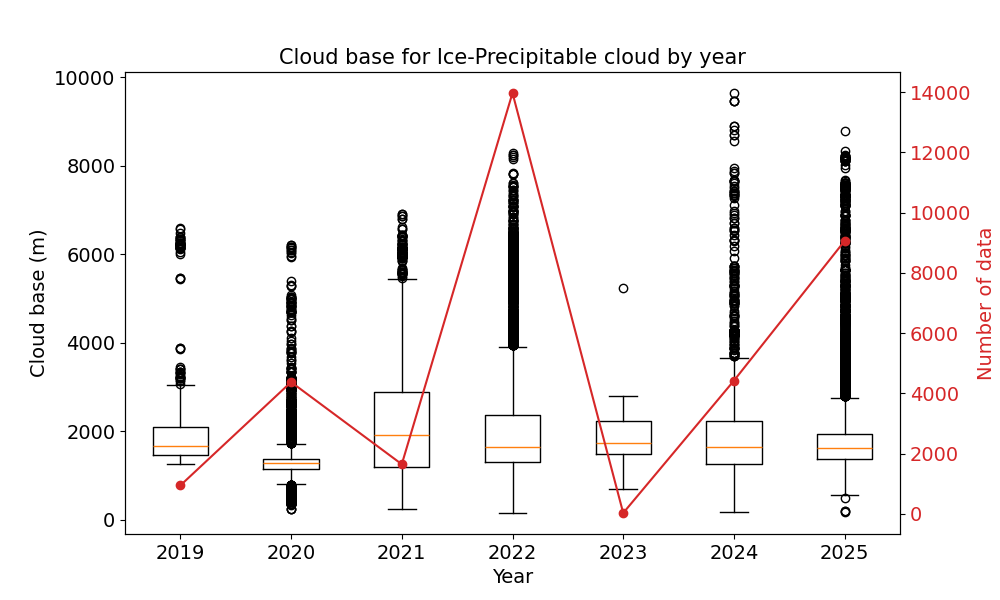

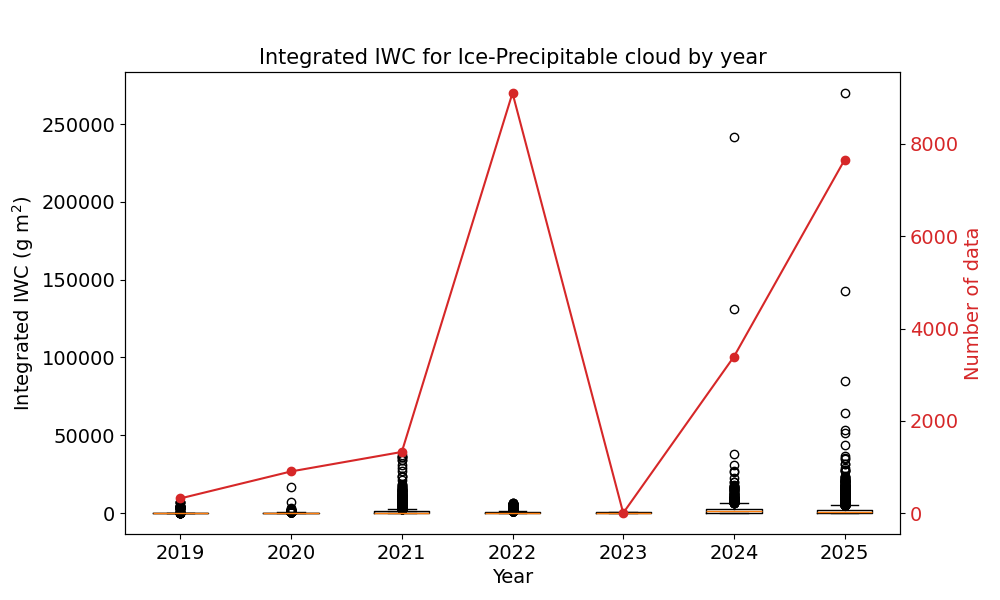

In [12]:
## Mean over the year macrophysics
cloud_types = list(ds_cloud_occurence.data_vars)[:-2]
layer = "single_layer"
macro = "cloud_base"
cloud = "Ice-Precipitable"
var ="iwc"
key = f"integrated_{var}_for_{cloud}"
ds_integrated = data[key]

ds_list = []
mask_to_remove = ds_atm_occurence.attenuation & ds_atm_occurence.noise.astype(bool)
mask_to_keep   = ds_cloud_occurence[cloud].values.astype(bool) & ds_atm_occurence[layer].values.astype(bool)

if macro == "cloud_thickness":
    ds = ds_structure[macro].where(~mask_to_remove).where(mask_to_keep)
else:
    ds = (ds_structure[macro] - 680.0).where(~mask_to_remove).where(mask_to_keep)

ds = ds.dropna(dim="time") # Remove NaN values

# Group by year and collect data for each year
years = ds['time.year'].values
unique_years = np.unique(years)
data_per_year = [ds.values[years == y] for y in unique_years]
counts_per_year = [len(arr) for arr in data_per_year]

plt.close('all')  # Close previous figures to avoid memory issues
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data_per_year, tick_labels=unique_years)
ax.set_xlabel("Year")
ax.set_ylabel(f"{macro.replace('_', ' ').capitalize()} (m)")
ax.set_title(f"{macro.replace('_', ' ').capitalize()} for {cloud} cloud by year")

# Add right y-axis for counts
ax2 = ax.twinx()
ax2.plot(np.arange(1, len(unique_years) + 1), counts_per_year, 'o-', color='tab:red', label='Count')
ax2.set_ylabel("Number of data", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.show()

years = ds_integrated['time.year'].values
data_per_year = [ds_integrated[f"integrated_{var}"].values[years == y] for y in unique_years]
counts_per_year = [len(arr) for arr in data_per_year]  # Close previous figures to avoid memory issues
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data_per_year, tick_labels=unique_years)
ax.set_xlabel("Year")
ax.set_ylabel(f"Integrated {var.upper()} (g m$^2$)")
ax.set_title(f"Integrated {var.upper()} for {cloud} cloud by year")
# Add right y-axis for counts
ax2 = ax.twinx()
ax2.plot(np.arange(1, len(unique_years) + 1), counts_per_year, 'o-', color='tab:red', label='Count')
ax2.set_ylabel("Number of data", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
plt.show()


In [19]:
cloud_types = list(ds_cloud_occurence.data_vars)[:-2]

for year in np.unique(ds_cloud_occurence[cloud].time.year.values):
    print(f"{year}")
    for cloud in cloud_types:
        cond = ds_atm_occurence[layer].values.astype(bool) & (ds_cloud_occurence[cloud].time.year.values == year)
        mean_value = ds_cloud_occurence[cloud].where(cond, 0).mean()
        
        print(f"{cloud}: {mean_value.values}")

2019.0
Liquid: 1.732188768982933e-05
Liquid-Precipitable: 0.0
Ice: 0.003538614199493706
Ice-Precipitable: 0.002343403948895482
Mixed-Phase: 0.0011778883629083945
Mixed-Phase-Precipitable: 0.002073677412010997
2020.0
Liquid: 0.00562466438842601
Liquid-Precipitable: 0.005330192297698911
Ice: 0.010395607169281859
Ice-Precipitable: 0.011355734658375256
Mixed-Phase: 0.005419276291532319
Mixed-Phase-Precipitable: 0.008787146169511992
2021.0
Liquid: 0.003236718442613823
Liquid-Precipitable: 0.0005963678476069812
Ice: 0.017886086317440913
Ice-Precipitable: 0.004389861251679604
Mixed-Phase: 0.007037635512839231
Mixed-Phase-Precipitable: 0.011558648199884686
2022.0
Liquid: 0.00354603786564649
Liquid-Precipitable: 0.00239536961196497
Ice: 0.017346633243671944
Ice-Precipitable: 0.035603902868752056
Mixed-Phase: 0.0037341040748503514
Mixed-Phase-Precipitable: 0.013018635876598872
2023.0
Liquid: 0.0002647774261159626
Liquid-Precipitable: 0.0003216921999539733
Ice: 0.0008537216075701599
Ice-Precipita

In [20]:

# cloud_type = ["Mixed-Phase-Precipitable"]
cloud_type = ["Mixed-Phase"]
variables = ["lwc", "iwc", "der", "ier"]

# cloud_type = ["Ice", "Ice-Precipitable"]
# variables = ["iwc",  "ier"]

# cloud_type = ["Liquid", "Liquid-Precipitable"]
# variables = ["lwc", "der"]

unique_cloud_types = np.unique(cloud_type)

# For each unique cloud type, build the lists of keys and merge datasets
ds_seasonal_dict = {}
ds_monthly_dict  = {}
ds_nvars_seasonal_dict = {}
ds_nvars_monthly_dict = {}
ds_npr_monthly_dict = {}

for ct in unique_cloud_types:
    data_vars_seasonal = [f"stats_{var}_for_{ct}_by_season" for var in variables]
    data_vars_monthly = [f"stats_{var}_for_{ct}_by_month" for var in variables]
    data_nvars_seasonal = [f"seasonal_{var}_for_{ct}_ndata_per_height_orig" for var in variables]
    data_nvars_monthly = [f"monthly_{var}_for_{ct}_ndata_per_height_orig" for var in variables]
    data_npr_monthly = [f"monthly_{var}_nprofile_for_{ct}" for var in variables]

    ds_seasonal_dict[ct] = xr.merge([data[var] for var in data_vars_seasonal if var in data])
    ds_monthly_dict[ct] = xr.merge([data[var] for var in data_vars_monthly if var in data])
    ds_nvars_seasonal_dict[ct] = xr.merge([data[var] for var in data_nvars_seasonal if var in data])
    ds_nvars_monthly_dict[ct] = xr.merge([data[var] for var in data_nvars_monthly if var in data])
    ds_npr_monthly_dict[ct] = xr.merge([data[var] for var in data_npr_monthly if var in data])
    

In [21]:
for ct in unique_cloud_types:
    ds_monthly  = ds_monthly_dict[ct]
    print(f"{ct}")
    for idx, var_name in enumerate(variables):
        print(f"{var_name}: {ds_monthly[f'integrated_{var_name}_annual_median'].item()}")
        

Mixed-Phase
lwc: 10.06281566619873
iwc: 2.0127365589141846
der: 10.294161796569824
ier: 44.45900344848633
